# S3  Preprocessing & EDA
## Explainable Machine Learning for Heart Disease Risk Prediction
**Autori:** Medina Ferhatović, Belmin Haračić

### Dataseti:
- **Dataset A:** `heart_2022_with_nans.csv` — CDC survey, osobni indikatori zdravlja (2022)
- **Dataset B:** `heart.csv` — klinički podaci o srčanoj insuficijenciji

### Šta radimo u ovom notebooku:
1. Učitavanje podataka
2. Provjera kvaliteta (missing values, duplikati)
3. Čišćenje podataka
4. Enkodiranje (tekst → brojevi)
5. Normalizacija
6. EDA vizualizacije

---
## 1. Import biblioteka

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Sve biblioteke uspjesno ucitane!')

Sve biblioteke uspjesno ucitane!


---
# DATASET A — CDC Heart Disease 2022
**Fajl:** `heart_2022_with_nans.csv`

## 2A. Ucitavanje Dataset A

In [18]:
# Ucitaj fajl (mora biti u istom folderu kao ovaj notebook)
df_a = pd.read_csv('heart_2022_with_nans.csv')

print(f'Broj redova:  {df_a.shape[0]:,}')
print(f'Broj kolona:  {df_a.shape[1]}')
print(f'Kolone: {list(df_a.columns)}')
df_a.head()

Broj redova:  445,132
Broj kolona:  40
Kolone: ['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


## 3A. Provjera kvaliteta podataka

In [19]:
print('=== TIPOVI PODATAKA ===')
print(df_a.dtypes)
print()

print('=== MISSING VALUES (prazna polja) ===')
missing = df_a.isnull().sum()
missing_pct = (missing / len(df_a) * 100).round(2)
missing_df = pd.DataFrame({'Broj praznih': missing, 'Postotak (%)': missing_pct})
missing_df = missing_df[missing_df['Broj praznih'] > 0].sort_values('Postotak (%)', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print('Nema missing values!')

print()
print(f'=== DUPLIKATI ===')
print(f'Broj duplikata: {df_a.duplicated().sum():,}')

=== TIPOVI PODATAKA ===
State                            str
Sex                              str
GeneralHealth                    str
PhysicalHealthDays           float64
MentalHealthDays             float64
LastCheckupTime                  str
PhysicalActivities               str
SleepHours                   float64
RemovedTeeth                     str
HadHeartAttack                   str
HadAngina                        str
HadStroke                        str
HadAsthma                        str
HadSkinCancer                    str
HadCOPD                          str
HadDepressiveDisorder            str
HadKidneyDisease                 str
HadArthritis                     str
HadDiabetes                      str
DeafOrHardOfHearing              str
BlindOrVisionDifficulty          str
DifficultyConcentrating          str
DifficultyWalking                str
DifficultyDressingBathing        str
DifficultyErrands                str
SmokerStatus                     str
ECigaretteUsag

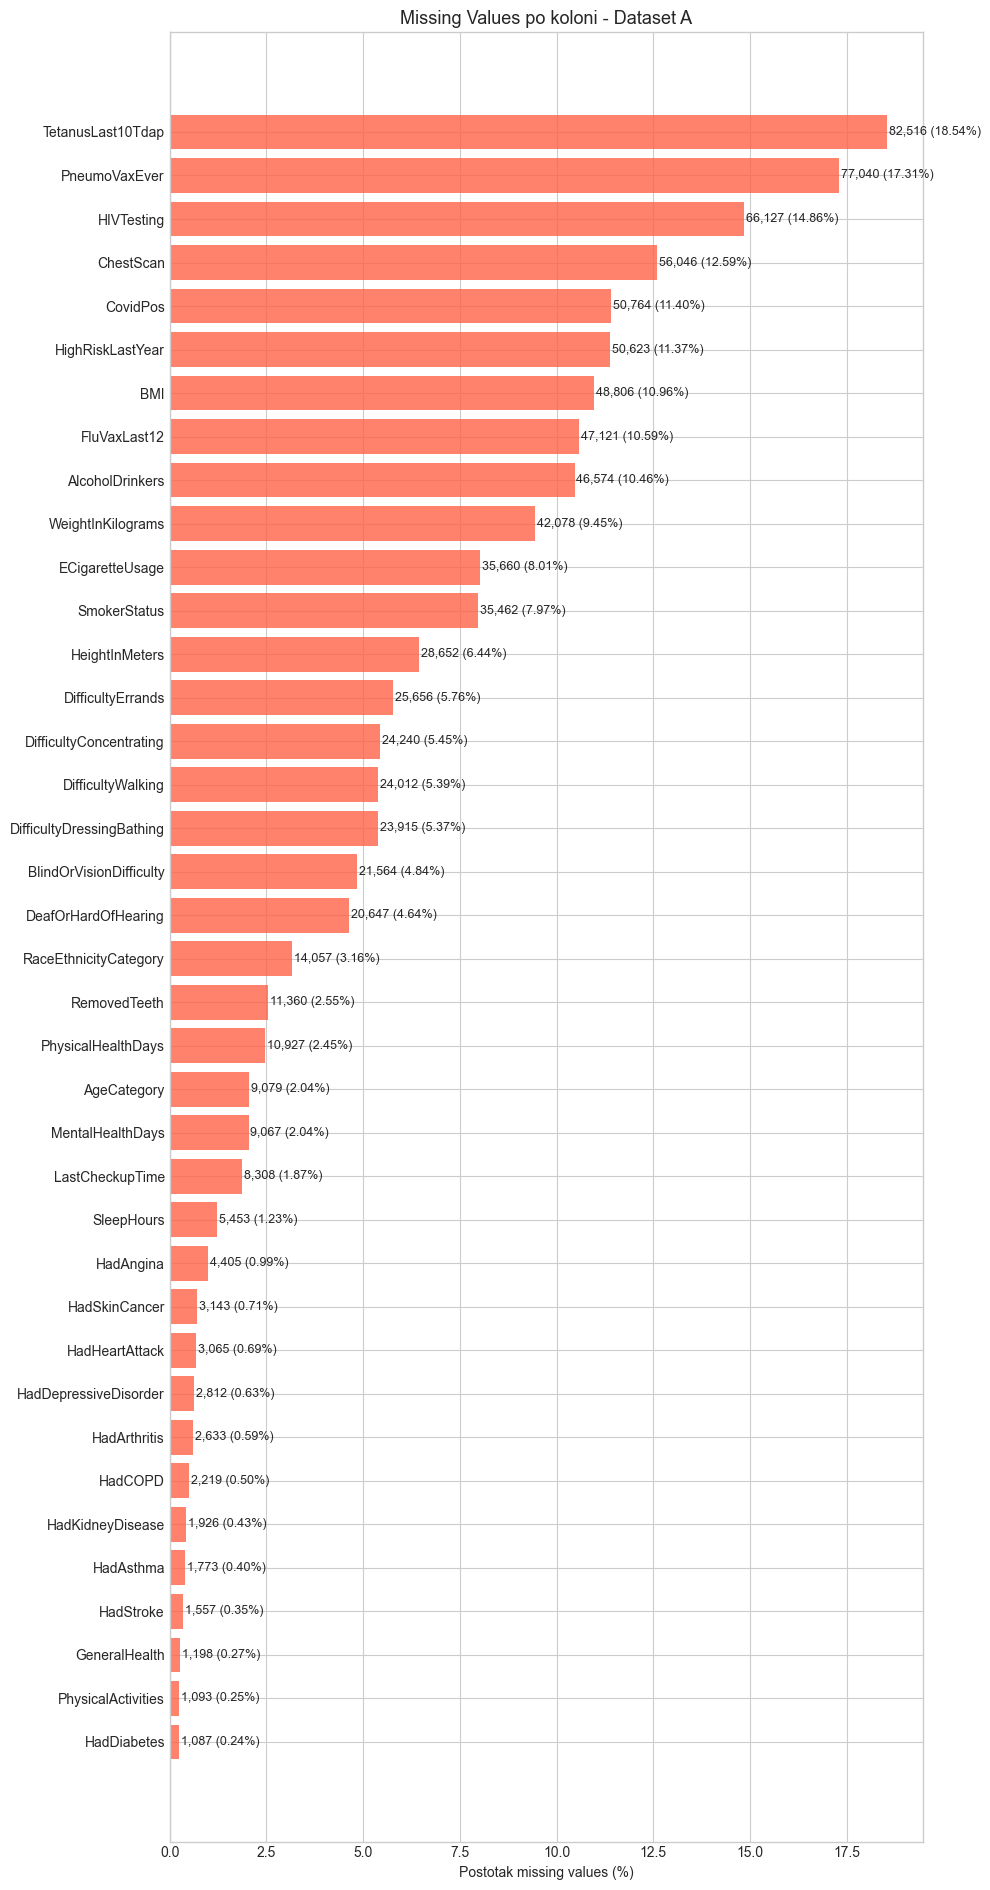

In [20]:
# Vizualizacija missing values
missing = df_a.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)

if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.5)))
    bars = ax.barh(missing.index, missing.values / len(df_a) * 100, color='tomato', alpha=0.8)
    ax.set_xlabel('Postotak missing values (%)')
    ax.set_title('Missing Values po koloni - Dataset A', fontsize=13)
    for bar, val in zip(bars, missing.values):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:,} ({val/len(df_a)*100:.2f}%)', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('dataset_a_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Nema missing values za prikazati.')

## 4A. Ciscenje podataka

In [21]:
df_a_clean = df_a.copy()

# Ukloni duplikate
before = len(df_a_clean)
df_a_clean = df_a_clean.drop_duplicates()
print(f'Duplikati uklonjeni: {before - len(df_a_clean)} redova')

# Popuni missing values
# Numericki -> median | Kategoricki -> modus (najcesca vrijednost)
num_cols = df_a_clean.select_dtypes(include=[np.number]).columns
cat_cols = df_a_clean.select_dtypes(include=['object']).columns

print('\nPopunjavanje missing values:')
for col in num_cols:
    if df_a_clean[col].isnull().sum() > 0:
        med = df_a_clean[col].median()
        df_a_clean[col].fillna(med, inplace=True)
        print(f'  Numericka [{col}]: popunjeno medianom ({med:.2f})')

for col in cat_cols:
    if df_a_clean[col].isnull().sum() > 0:
        mod = df_a_clean[col].mode()[0]
        df_a_clean[col].fillna(mod, inplace=True)
        print(f'  Kategoricka [{col}]: popunjeno modom ("{mod}")')

print(f'\nMissing values preostalo: {df_a_clean.isnull().sum().sum()}')
print(f'Konacni broj redova: {len(df_a_clean):,}')

Duplikati uklonjeni: 157 redova

Popunjavanje missing values:
  Numericka [PhysicalHealthDays]: popunjeno medianom (0.00)
  Numericka [MentalHealthDays]: popunjeno medianom (0.00)
  Numericka [SleepHours]: popunjeno medianom (7.00)
  Numericka [HeightInMeters]: popunjeno medianom (1.70)
  Numericka [WeightInKilograms]: popunjeno medianom (80.74)
  Numericka [BMI]: popunjeno medianom (27.44)
  Kategoricka [GeneralHealth]: popunjeno modom ("Very good")
  Kategoricka [LastCheckupTime]: popunjeno modom ("Within past year (anytime less than 12 months ago)")
  Kategoricka [PhysicalActivities]: popunjeno modom ("Yes")
  Kategoricka [RemovedTeeth]: popunjeno modom ("None of them")
  Kategoricka [HadHeartAttack]: popunjeno modom ("No")
  Kategoricka [HadAngina]: popunjeno modom ("No")
  Kategoricka [HadStroke]: popunjeno modom ("No")
  Kategoricka [HadAsthma]: popunjeno modom ("No")
  Kategoricka [HadSkinCancer]: popunjeno modom ("No")
  Kategoricka [HadCOPD]: popunjeno modom ("No")
  Kategoric

## 5A. EDA — Vizualizacije

In [22]:
# VAZNO: Provjeri kako se zove target kolona u tvom datasetu!
# Pokreni ovu celiju da vidis kolone i nadi pravu
print('Sve kolone u Dataset A:')
for i, col in enumerate(df_a_clean.columns):
    print(f'  {i}: {col}')

Sve kolone u Dataset A:
  0: State
  1: Sex
  2: GeneralHealth
  3: PhysicalHealthDays
  4: MentalHealthDays
  5: LastCheckupTime
  6: PhysicalActivities
  7: SleepHours
  8: RemovedTeeth
  9: HadHeartAttack
  10: HadAngina
  11: HadStroke
  12: HadAsthma
  13: HadSkinCancer
  14: HadCOPD
  15: HadDepressiveDisorder
  16: HadKidneyDisease
  17: HadArthritis
  18: HadDiabetes
  19: DeafOrHardOfHearing
  20: BlindOrVisionDifficulty
  21: DifficultyConcentrating
  22: DifficultyWalking
  23: DifficultyDressingBathing
  24: DifficultyErrands
  25: SmokerStatus
  26: ECigaretteUsage
  27: ChestScan
  28: RaceEthnicityCategory
  29: AgeCategory
  30: HeightInMeters
  31: WeightInKilograms
  32: BMI
  33: AlcoholDrinkers
  34: HIVTesting
  35: FluVaxLast12
  36: PneumoVaxEver
  37: TetanusLast10Tdap
  38: HighRiskLastYear
  39: CovidPos


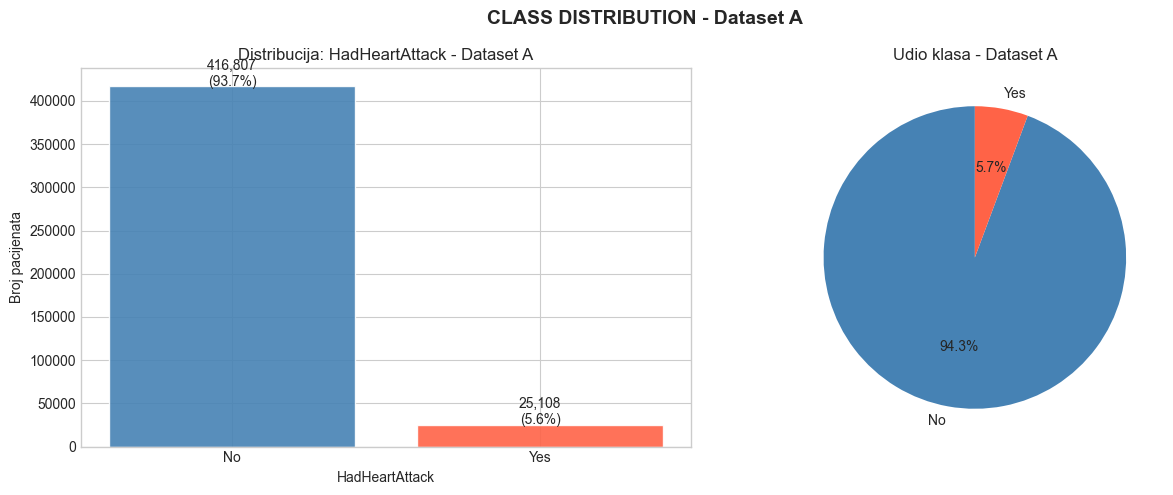

Omjer klasa: 16.6:1
NAPOMENA: Dataset je imbalanced (neuravnotezen)!


In [23]:
# Postavi naziv target kolone (srcan udar / heart disease)
# Vjerovatno je 'HadHeartAttack' u 2022 datasetu
target_col_a = 'HadHeartAttack'  # <- PROMIJENI ako treba!

# Distribucija klasa
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts = df_a_clean[target_col_a].value_counts()
colors = ['steelblue', 'tomato']

axes[0].bar(counts.index.astype(str), counts.values, color=colors, edgecolor='white', alpha=0.9)
axes[0].set_title(f'Distribucija: {target_col_a} - Dataset A', fontsize=12)
axes[0].set_xlabel(target_col_a)
axes[0].set_ylabel('Broj pacijenata')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df_a_clean)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=counts.index.astype(str), autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Udio klasa - Dataset A', fontsize=12)

plt.suptitle('CLASS DISTRIBUTION - Dataset A', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_a_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = counts.values[0] / counts.values[1]
print(f'Omjer klasa: {ratio:.1f}:1')
if ratio > 3:
    print('NAPOMENA: Dataset je imbalanced (neuravnotezen)!')

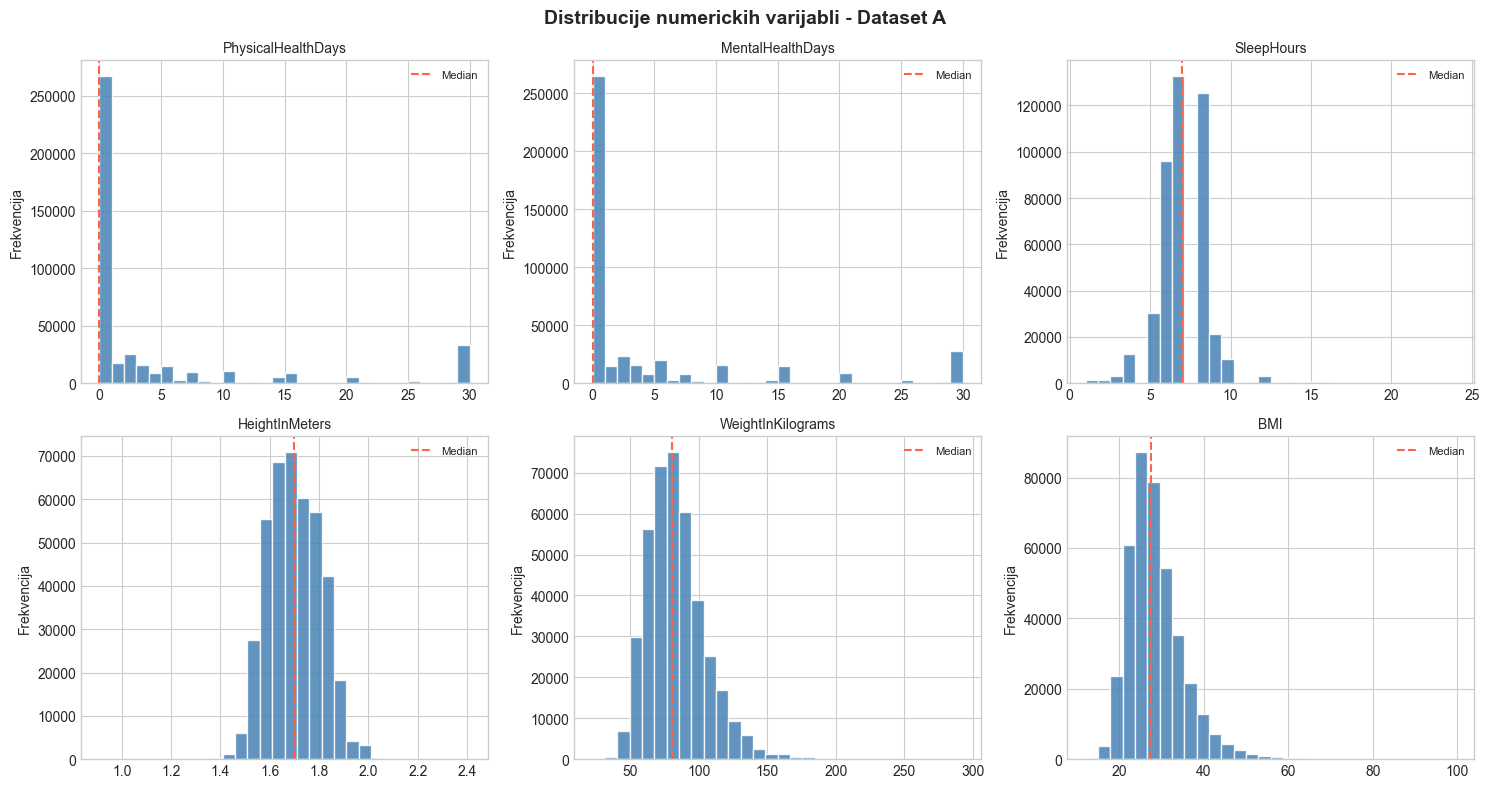

In [24]:
# Histogrami numeričkih varijabli
num_cols_a = df_a_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols_a = [c for c in num_cols_a if c != target_col_a]

if len(num_cols_a) > 0:
    n_cols = 3
    n_rows = (len(num_cols_a) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(num_cols_a):
        axes[i].hist(df_a_clean[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
        axes[i].axvline(df_a_clean[col].median(), color='tomato', linestyle='--', linewidth=1.5, label='Median')
        axes[i].set_title(col, fontsize=10)
        axes[i].set_ylabel('Frekvencija')
        axes[i].legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribucije numerickih varijabli - Dataset A', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('dataset_a_histograms.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Nema numerickih kolona za prikaz.')

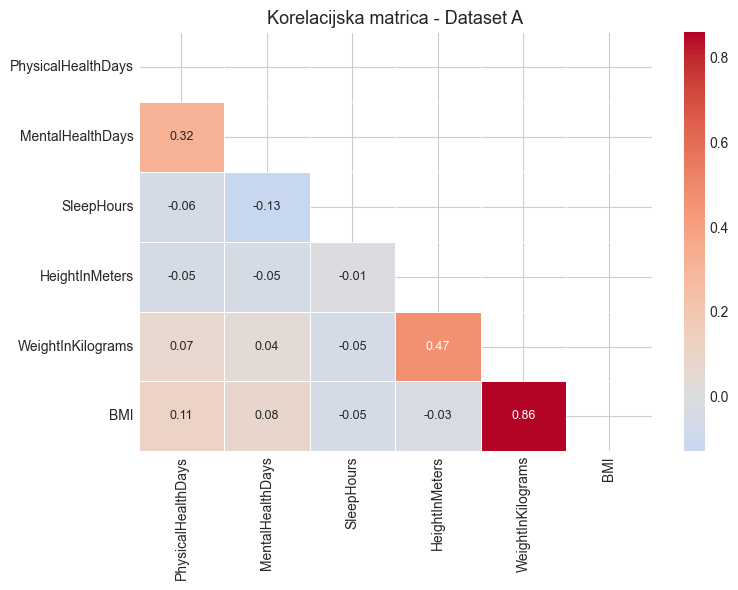

In [25]:
# Korelacijska matrica
all_num_a = df_a_clean.select_dtypes(include=[np.number]).columns.tolist()

if len(all_num_a) > 1:
    fig, ax = plt.subplots(figsize=(max(8, len(all_num_a)), max(6, len(all_num_a) - 1)))
    corr = df_a_clean[all_num_a].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                mask=mask, ax=ax, linewidths=0.5, annot_kws={'size': 9})
    ax.set_title('Korelacijska matrica - Dataset A', fontsize=13)
    plt.tight_layout()
    plt.savefig('dataset_a_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Nema dovoljno numerickih kolona za korelacijsku matricu.')

## 6A. Preprocessing — Enkodiranje i Normalizacija

In [26]:
df_a_processed = df_a_clean.copy()

# Enkodiranje: tekst -> brojevi
le = LabelEncoder()
cat_cols_a = df_a_processed.select_dtypes(include=['object']).columns.tolist()

print('Enkodiranje kategorickih varijabli:')
for col in cat_cols_a:
    sample = df_a_processed[col].unique()[:3]
    df_a_processed[col] = le.fit_transform(df_a_processed[col].astype(str))
    print(f'  {col}: {sample} -> brojevi')

# Normalizacija: sve varijable na isti raspon (mean=0, std=1)
feature_cols_a = [c for c in df_a_processed.columns if c != target_col_a]
X_a = df_a_processed[feature_cols_a]
y_a = df_a_processed[target_col_a]

scaler_a = StandardScaler()
X_a_scaled = pd.DataFrame(scaler_a.fit_transform(X_a), columns=feature_cols_a)

print(f'\nNormalizacija zavrsena!')
print(f'Features (X) shape: {X_a_scaled.shape}')
print(f'Target   (y) shape: {y_a.shape}')
print(f'Klase u targetu:    {y_a.unique()}')

Enkodiranje kategorickih varijabli:
  State: <StringArray>
['Alabama', 'Alaska', 'Arizona']
Length: 3, dtype: str -> brojevi
  Sex: <StringArray>
['Female', 'Male']
Length: 2, dtype: str -> brojevi
  GeneralHealth: <StringArray>
['Very good', 'Excellent', 'Fair']
Length: 3, dtype: str -> brojevi
  LastCheckupTime: <StringArray>
[    'Within past year (anytime less than 12 months ago)',
                                                      nan,
 'Within past 2 years (1 year but less than 2 years ago)']
Length: 3, dtype: str -> brojevi
  PhysicalActivities: <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str -> brojevi
  RemovedTeeth: <StringArray>
[nan, 'None of them', '1 to 5']
Length: 3, dtype: str -> brojevi
  HadHeartAttack: <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str -> brojevi
  HadAngina: <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str -> brojevi
  HadStroke: <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str -> brojevi
  HadAsthma: <StringArray>
['No', '

---
# DATASET B — Heart Failure Prediction
**Fajl:** `heart.csv`

## 2B. Ucitavanje Dataset B

In [27]:
df_b = pd.read_csv('heart.csv')

print(f'Broj redova:  {df_b.shape[0]:,}')
print(f'Broj kolona:  {df_b.shape[1]}')
print(f'Kolone: {list(df_b.columns)}')
df_b.head()

Broj redova:  918
Broj kolona:  12
Kolone: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 3B. Provjera kvaliteta podataka

In [28]:
print('=== TIPOVI PODATAKA ===')
print(df_b.dtypes)
print()

print('=== MISSING VALUES ===')
missing_b = df_b.isnull().sum()
missing_b_df = pd.DataFrame({
    'Broj praznih': missing_b,
    'Postotak (%)': (missing_b / len(df_b) * 100).round(2)
})
missing_b_df = missing_b_df[missing_b_df['Broj praznih'] > 0]
if len(missing_b_df) > 0:
    print(missing_b_df)
else:
    print('Nema missing values!')

print()
print(f'=== DUPLIKATI ===')
print(f'Broj duplikata: {df_b.duplicated().sum()}')

print()
print('=== STATISTIKE ===')
df_b.describe()

=== TIPOVI PODATAKA ===
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

=== MISSING VALUES ===
Nema missing values!

=== DUPLIKATI ===
Broj duplikata: 0

=== STATISTIKE ===


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## 4B. Ciscenje podataka

In [29]:
df_b_clean = df_b.copy()

before = len(df_b_clean)
df_b_clean = df_b_clean.drop_duplicates()
print(f'Duplikati uklonjeni: {before - len(df_b_clean)}')

num_cols_b = df_b_clean.select_dtypes(include=[np.number]).columns
cat_cols_b = df_b_clean.select_dtypes(include=['object']).columns

print('Popunjavanje missing values:')
for col in num_cols_b:
    if df_b_clean[col].isnull().sum() > 0:
        med = df_b_clean[col].median()
        df_b_clean[col].fillna(med, inplace=True)
        print(f'  [{col}]: median ({med:.2f})')

for col in cat_cols_b:
    if df_b_clean[col].isnull().sum() > 0:
        mod = df_b_clean[col].mode()[0]
        df_b_clean[col].fillna(mod, inplace=True)
        print(f'  [{col}]: modus ("{mod}")')

print(f'Missing values preostalo: {df_b_clean.isnull().sum().sum()}')
print(f'Konacni broj redova: {len(df_b_clean)}')

Duplikati uklonjeni: 0
Popunjavanje missing values:
Missing values preostalo: 0
Konacni broj redova: 918


## 5B. EDA — Vizualizacije

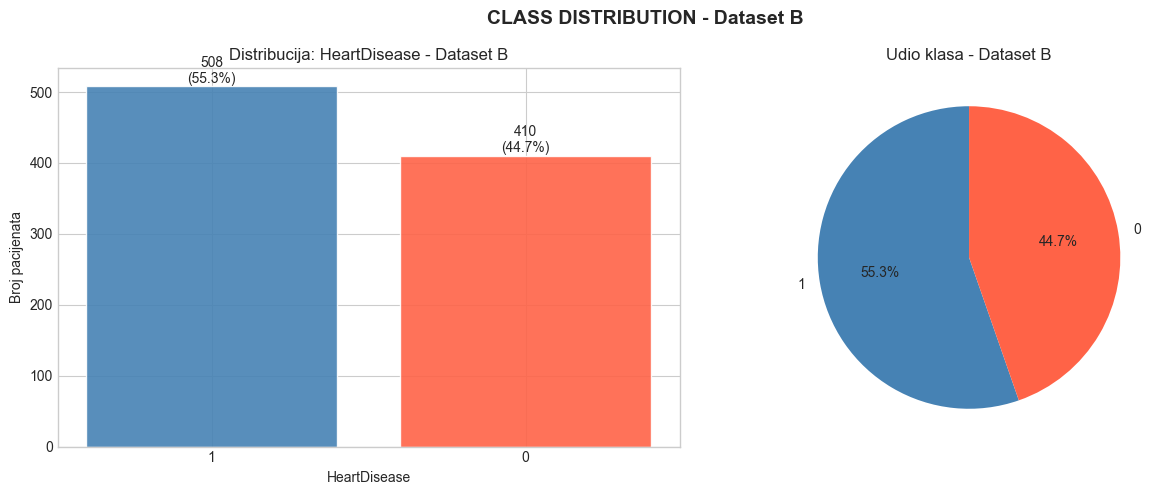

In [30]:
target_col_b = 'HeartDisease'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts_b = df_b_clean[target_col_b].value_counts()
colors = ['steelblue', 'tomato']

axes[0].bar(counts_b.index.astype(str), counts_b.values, color=colors, edgecolor='white', alpha=0.9)
axes[0].set_title(f'Distribucija: {target_col_b} - Dataset B', fontsize=12)
axes[0].set_xlabel(target_col_b)
axes[0].set_ylabel('Broj pacijenata')
for i, v in enumerate(counts_b.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df_b_clean)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(counts_b.values, labels=counts_b.index.astype(str), autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Udio klasa - Dataset B', fontsize=12)

plt.suptitle('CLASS DISTRIBUTION - Dataset B', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_b_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

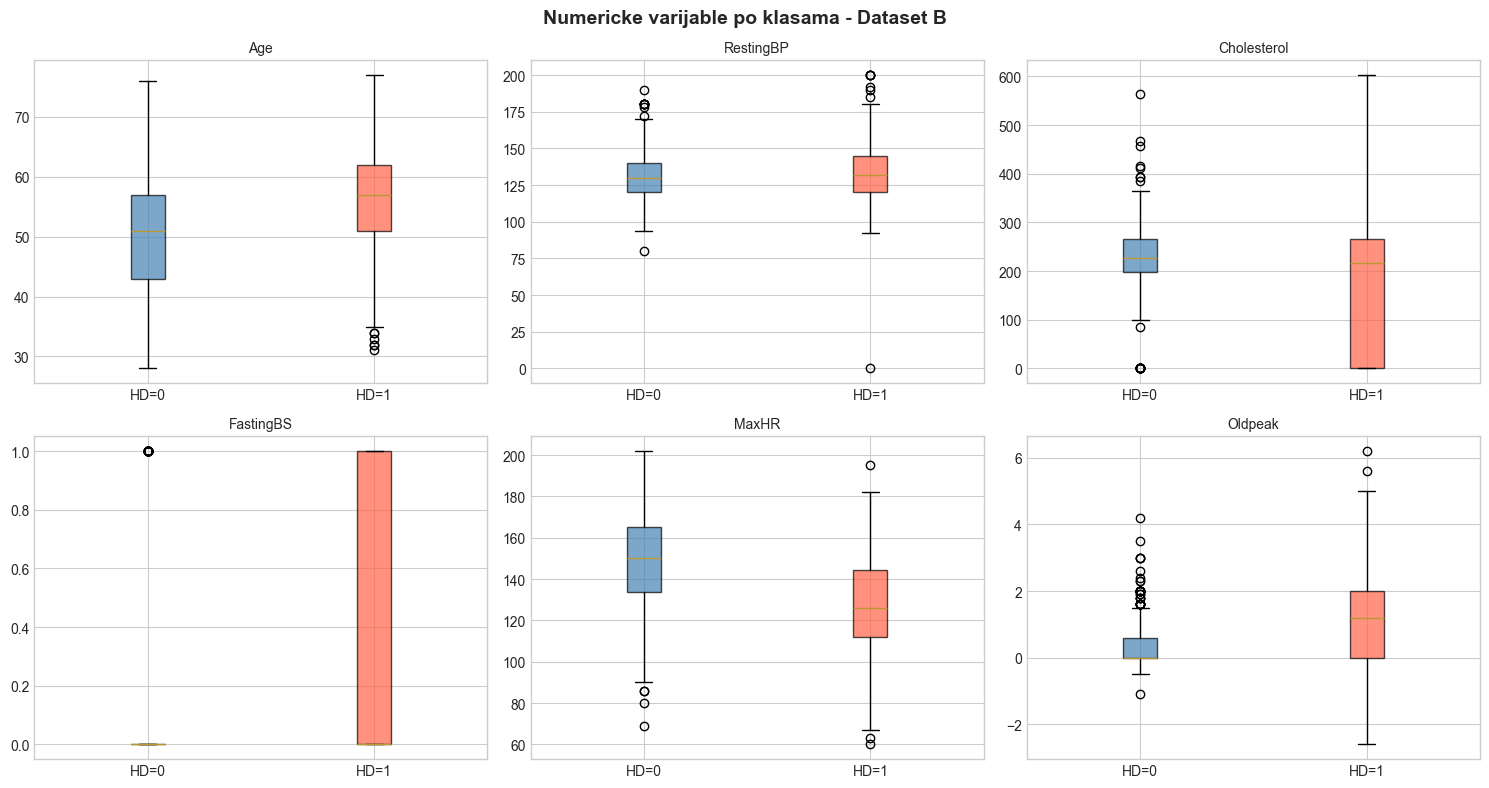

In [31]:
# Boxploti — numeričke varijable po klasi
num_cols_b_vis = df_b_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols_b_vis = [c for c in num_cols_b_vis if c != target_col_b]

n_cols = 3
n_rows = (len(num_cols_b_vis) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_b_vis):
    groups = [df_b_clean[df_b_clean[target_col_b] == v][col].dropna()
              for v in sorted(df_b_clean[target_col_b].unique())]
    labels = [f'HD={v}' for v in sorted(df_b_clean[target_col_b].unique())]
    bp = axes[i].boxplot(groups, patch_artist=True, labels=labels)
    for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numericke varijable po klasama - Dataset B', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_b_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

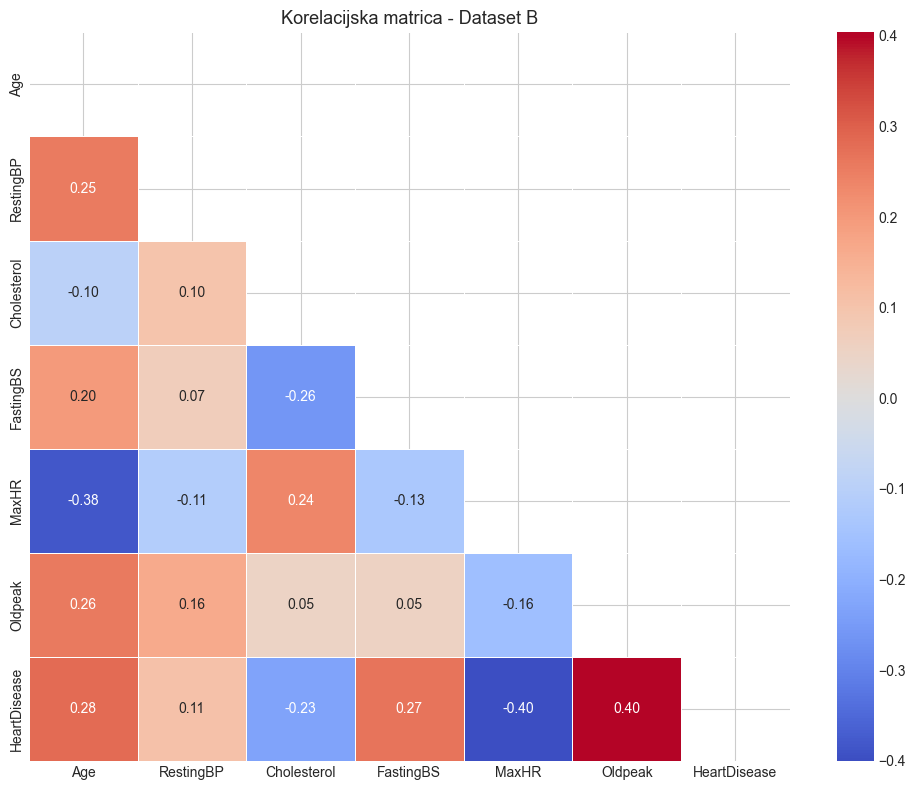

In [32]:
# Korelacijska matrica — Dataset B
all_num_b = df_b_clean.select_dtypes(include=[np.number]).columns.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
corr_b = df_b_clean[all_num_b].corr()
mask = np.triu(np.ones_like(corr_b, dtype=bool))
sns.heatmap(corr_b, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Korelacijska matrica - Dataset B', fontsize=13)
plt.tight_layout()
plt.savefig('dataset_b_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6B. Preprocessing — Enkodiranje i Normalizacija

In [33]:
df_b_processed = df_b_clean.copy()

le2 = LabelEncoder()
cat_cols_b_enc = df_b_processed.select_dtypes(include=['object']).columns.tolist()

print('Enkodiranje kategorickih varijabli:')
for col in cat_cols_b_enc:
    sample = df_b_processed[col].unique()[:3]
    df_b_processed[col] = le2.fit_transform(df_b_processed[col].astype(str))
    print(f'  {col}: {sample} -> brojevi')

feature_cols_b = [c for c in df_b_processed.columns if c != target_col_b]
X_b = df_b_processed[feature_cols_b]
y_b = df_b_processed[target_col_b]

scaler_b = StandardScaler()
X_b_scaled = pd.DataFrame(scaler_b.fit_transform(X_b), columns=feature_cols_b)

print(f'\nNormalizacija zavrsena!')
print(f'Features (X) shape: {X_b_scaled.shape}')
print(f'Target   (y) shape: {y_b.shape}')
print(f'Klase u targetu: {sorted(y_b.unique())}')

Enkodiranje kategorickih varijabli:
  Sex: <StringArray>
['M', 'F']
Length: 2, dtype: str -> brojevi
  ChestPainType: <StringArray>
['ATA', 'NAP', 'ASY']
Length: 3, dtype: str -> brojevi
  RestingECG: <StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str -> brojevi
  ExerciseAngina: <StringArray>
['N', 'Y']
Length: 2, dtype: str -> brojevi
  ST_Slope: <StringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str -> brojevi

Normalizacija zavrsena!
Features (X) shape: (918, 11)
Target   (y) shape: (918,)
Klase u targetu: [np.int64(0), np.int64(1)]


---
# 7. Finalna usporedba i cuvanje

In [34]:
print('=' * 55)
print('   SUMMARY - USPOREDBA DATASETA')
print('=' * 55)
print(f"{'Karakteristika':<35} {'Dataset A':>10} {'Dataset B':>10}")
print('-' * 55)
print(f"{'Broj uzoraka':<35} {len(df_a_clean):>10,} {len(df_b_clean):>10,}")
print(f"{'Broj feature-a':<35} {X_a_scaled.shape[1]:>10} {X_b_scaled.shape[1]:>10}")
print(f"{'Tip dataseta':<35} {'Survey CDC':>10} {'Klinicki':>10}")
print(f"{'Missing values (nakon)':<35} {df_a_clean.isnull().sum().sum():>10} {df_b_clean.isnull().sum().sum():>10}")
print('=' * 55)

   SUMMARY - USPOREDBA DATASETA
Karakteristika                       Dataset A  Dataset B
-------------------------------------------------------
Broj uzoraka                           444,975        918
Broj feature-a                              39         11
Tip dataseta                        Survey CDC   Klinicki
Missing values (nakon)                  899788          0


In [35]:
# Sacuvaj preprocessovane datasete za S4 (treniranje modela)
df_a_final = X_a_scaled.copy()
df_a_final[target_col_a] = y_a.values
df_a_final.to_csv('dataset_a_preprocessed.csv', index=False)

df_b_final = X_b_scaled.copy()
df_b_final[target_col_b] = y_b.values
df_b_final.to_csv('dataset_b_preprocessed.csv', index=False)

print('Sacuvano:')
print('  -> dataset_a_preprocessed.csv')
print('  -> dataset_b_preprocessed.csv')
print()
print('S3 - Preprocessing & EDA ZAVRSEN!')

Sacuvano:
  -> dataset_a_preprocessed.csv
  -> dataset_b_preprocessed.csv

S3 - Preprocessing & EDA ZAVRSEN!
